<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-ZapataGonzalez/Evaluacion2/ZapataGonzalez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# !sudo apt-get install texlive-latex-recommended
# !pip install pdflatex
# !pip install --upgrade jax jaxlib
# !sudo apt-get update
# !sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np


from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')
 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
 # Configuración Estética Definitiva para Google Colab (Fuerza LaTeX real del sistema)
plt.rcParams.update({
    "text.usetex": True,                     # ¡ACTIVAMOS EL COMPILADOR REAL DE LATEX!
    "font.family": "serif",                  # Familia serif obligatoria
    "font.serif": ["Computer Modern Roman"], # Fuente académica por excelencia
    "text.latex.preamble": r"\usepackage[utf8]{inputenc} \usepackage[T1]{fontenc} \usepackage{amsmath}", # Soporte nativo para español
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Estética de guardado
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print('Configuración de Fuentes Científicas con LaTeX Real OK')

Configuración de Fuentes Científicas con LaTeX Real OK


# Capa Fourier
Función que construye la capa de Fourier, comparación con np.fft y reporte de energía

In [10]:
from matplotlib import figure
import jax #para la diferenciación automática
import jax.numpy as jnp
from jax import grad, jit, vmap
import numpy as np
import matplotlib.pyplot as plt

# Configuración de parámetros establecidos por el enunciado
K = 25              # Número de frecuencias
hidden_dim = 2 * K  # 2K = 50 neuronas ocultas, 2 neuronas por frecuencia
n_features = 256    # Tamaño de la señal (t)
eta = 0.02          # Learning rate (segun enunciado_3951: eta=0.02)
iteraciones = 3000  # Número de iteraciones

# Carga de datos correspondientes a la cédula 3951
datos = np.load("../SolucionReferencia_0000/datos_0000.npz") #carga el archivo que tiene el arrglo de datos
X_train = jnp.array(datos['X']) #carga las señales de entrada a un arreglo de JAX
y_train = np.array(datos['y']) #CARGA las etiquetas de los regímenes
t = jnp.array(datos['t']) #converite el vector de tiempo a un arrelgo inmutable de JAX



In [11]:

# 1. FUNCIÓN QUE CONSTRUYE LA CAPA FOURIER, inicialización física
def construir_capa_fourier(n_features=256, K=25):
    t_arr = jnp.linspace(0, 1, n_features, endpoint=False) #genera un vector de tiempo equiespaciado entre 0 y 1 con un tamaño de 256 puntos
    W1_list = [] #lista para guardar los vectores de onda
    #este bucle construye pares de las funciones seno y coseno para cada frecuencia
    for k in range(1, K + 1):
        W1_list.append(jnp.sin(2 * jnp.pi * k * t_arr)) #construye el vector de seno
        W1_list.append(jnp.cos(2 * jnp.pi * k * t_arr)) #construye el vecto de coseno
    return jnp.stack(W1_list, axis=0) #esos vectores los guarda verticalmente para asi formar una matriz 50x256

#genera la matriz de pesos iniciales de Fourier, usando la función anterior
W1_fourier_init = construir_capa_fourier(n_features, K)

# 2. ARQUITECTURA DE LA RED NEURONAL (Dos capas: W1 -> tanh -> W2) foward para una sola señal
def forward(params, x): #vamos a procesar una señal
    phi = jnp.tanh(jnp.dot(params['W1'], x)) #producto punto entre W1 y x, al que le aplica la funcion de activación.
    x_hat = jnp.dot(params['W2'], phi) #producto punto entre la matriz W2 y lo guardado en phi
    return x_hat #retorna el vector de la señal reconstruida

#vectoriación automática(vmap): tranforma la función forward para que pueda procesar un grupo completo de señales de manera paralela y automatica.
forward_batch = vmap(forward, in_axes=(None, 0)) #in_axes=(None, 0) significa que los parametros se van a mantener fijos y las señales se recorren sobre el eje 0.

# 3. FUNCION DE PERDIDA GLOBAL (MSE)
@jit #compila la funcion en codigo de maquina optimizado solo en la primera ejecutación
#traduce mi codigo de alto nivel a un codigo binario para que el procesador lo pueda entender de una
def loss_fn(params, X):
    X_hat = forward_batch(params, X) #genera las reconstrucciones de todos los ltes de sañales
    return jnp.mean((X_hat - X) ** 2) #Calcula el error cuadatrico medio (MES) entre la prediccion y el valor real

# 4. ALGORITMO DE OPTIMIZACION: gradiente descendente
@jit #complia el paso de actualización para celerar el entrenamiento
def update(params, X, lr):
    grads = grad(loss_fn)(params, X) #calcula automaticamente las derivadas parciales exactas del MSE respecto W1 y W2
    #aplica la regla del gradiente: peso_nuevo=peso_anterior-(learning_rate*gradiente)
    updated_params = {
        'W1': params['W1'] - lr * grads['W1'],
        'W2': params['W2'] - lr * grads['W2']
    }
    return updated_params #retorna los pesos actualializados de la red

#Reporte de datos
energia_media = float((X_train**2).mean()) #calcula la energia media total en todo el dataset de señales
print("CAPA FOURIER Y ENERGÍA")
print(f"Energía media del dataset ((X**2).mean()): {energia_media:.3f}\n")


# Poryecta la primera señal del dataset sobre los pesos sacados de la capa de Fourier
proyeccion = jnp.dot(W1_fourier_init, X_train[0])
#calcula la magnitud combinada del primer armonico uniendo la componente seno con la coseno
mag_capa_k1 = jnp.sqrt(proyeccion[0]**2 + proyeccion[1]**2)

#Hace la transformada rápida de Fourier clásica que tiene NumPy para señales
fft_np = np.fft.fft(X_train[0])
#extrae el valor absoluto del termino correspondiente a la frencuencia
mag_fft_k1 = np.abs(fft_np[1])

print("EVIDENCIA DE TRANSFORMADA DE FOURIER (k=1):")
print(f"Magnitud calculada por Capa W1:  {mag_capa_k1:.6f}")
print(f"Magnitud calculada por np.fft:   {mag_fft_k1:.6f}")
print(f"Diferencia absoluta:             {abs(mag_capa_k1 - mag_fft_k1):.2e}")


CAPA FOURIER Y ENERGÍA
Energía media del dataset ((X**2).mean()): 0.678

EVIDENCIA DE TRANSFORMADA DE FOURIER (k=1):
Magnitud calculada por Capa W1:  1.756592
Magnitud calculada por np.fft:   1.756592
Diferencia absoluta:             3.58e-07


# Función de la red
Con las dos inicializaciones con los parámetros dados por el enunciado

In [12]:

#DEFINICION DE LA RED NEURONAL PARALELA PARA LAS DOS INICALIZACIONES
def entrenar_red_fourier(X_train, y_train, W1_fourier_init, K=25, eta=0.05, iteraciones=3000, seed=0000):
    """
    Entrena dos variantes de una red neuronal (inicialización aleatoria vs Fourier)
    y devuelve los historiales de métricas.
    """
    # 1. Configuración de dimensiones basadas en los argumentos
    hidden_dim = 2 * K #el ancho de la capa oculta basando en el numero de frecuencias
    n_features = X_train.shape[1] # Se adapta automáticamente al tamaño de la señal leyendo de manera autmatica la cantidad de puntos de tiempo

    # 2. Inicialización de llaves JAX y parámetros
    key = jax.random.PRNGKey(seed) #inicia el generador de numeros aleatorios de JAXa con la semilla
    k1, k2 = jax.random.split(key) #divide la semilla para asegurar inicializaciones distintas
    #3. Inicializa los pesos aleatorios usando una dsitrbución normal escalada pequeña (0.01)
    params_rand = {
        'W1': jax.random.normal(k1, (hidden_dim, n_features)) * 0.01,
        'W2': jax.random.normal(k2, (n_features, hidden_dim)) * 0.01
    }
    #4. Inicia los pesos de Fourier con la matriz física en W1 y una matriz aleatoria en W2
    params_four = {
        'W1': W1_fourier_init,
        'W2': jax.random.normal(k2, (n_features, hidden_dim)) * 0.01
    }

    # 5. Historiales para recolectar los historiales paso a paso
    historiales = {
        'loss_rand': [], 'loss_four': [],
        'err_rand_global': [], 'err_four_global': [],
        'err_rand_r0': [], 'err_four_r0': []
    }

    # 6. Función para el error relativo ||x_pred-x_real||/||x_real||
    def calcular_error_relativo_lote(X_real, X_pred):
        norma_error = np.linalg.norm(X_pred - X_real, axis=1) #normal euclídea de la resta fila por fila
        norma_real = np.linalg.norm(X_real, axis=1) #norma euclídea de la señal real de referencia
        return norma_error / norma_real #vector resultante con los errores individuales
  #Genera copias locales de trabajo de las arquitecturas iniciales para iniciar la optimización
    p_rand = params_rand.copy()
    p_four = params_four.copy()
    # Encuentra la ubicación exacta en filas donde el Régimen de dispersión es estrictamente igual a cero (el pedido)
    idx_regimen_foco = np.where(y_train == 0)[0]  # REGIMEN FOCO = 0 (segun enunciado_3951)

    print(f"Entrenando redes (K={K}, eta={eta}, iteraciones={iteraciones})...")

    # 7. BUCLE PRINCIPAL DE ENTRENAMIENTO
    for i in range(iteraciones + 1):
      # Actualiza los parámetros de ambos modelos mediante optimización por gradiente descendente
        p_rand = update(p_rand, X_train, eta)
        p_four = update(p_four, X_train, eta)
        # Evalúa y registra el valor numérico actual del costo global (MSE)
        loss_r = loss_fn(p_rand, X_train) #loss_fn es la funcion de perdida,mide que tan equivocado esta el modelo comparando lo predicho con lo real
        loss_f = loss_fn(p_four, X_train)
        historiales['loss_rand'].append(loss_r)
        historiales['loss_four'].append(loss_f)
        # Genera las predicciones actuales de reconstrucción temporal para todo el conjunto
        x_hat_r_curr = np.array(forward_batch(p_rand, X_train)) #forward_batch es el proceso en el que un lote que pasa por la red
        x_hat_f_curr = np.array(forward_batch(p_four, X_train))
        # Calcula la matriz de errores relativos individuales actuales llamando la funcion de arriba
        err_r_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_r_curr)
        err_f_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_f_curr)
        # Saca el promedio global del error para todo el conjunto de datos y lo guarda
        historiales['err_rand_global'].append(np.mean(err_r_individual)) #np.mean calcula el promedio de los datos
        historiales['err_four_global'].append(np.mean(err_f_individual))
        # Filtra el error usando los índices del Régimen 0, saca el promedio exclusivo y lo guarda
        historiales['err_rand_r0'].append(np.mean(err_r_individual[idx_regimen_foco]))
        historiales['err_four_r0'].append(np.mean(err_f_individual[idx_regimen_foco]))

    return historiales, p_rand, p_four # Devuelve todas las curvas del entrenamiento y las matrices optimizadas



# Señal original junto a su reconstrucción final
 Para una señal de cada régimen junto al reporte del error relativo de reconstrucción de cada caso.

Entrenando redes (K=25, eta=0.02, iteraciones=3000)...
ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN
Régimen 0 (mu=0.0): Fourier Err = 0.6308 | Aleatorio Err = 0.7234
Régimen 1 (mu=5.0): Fourier Err = 0.5541 | Aleatorio Err = 0.6370
Régimen 2 (mu=15.0): Fourier Err = 0.7559 | Aleatorio Err = 0.8631




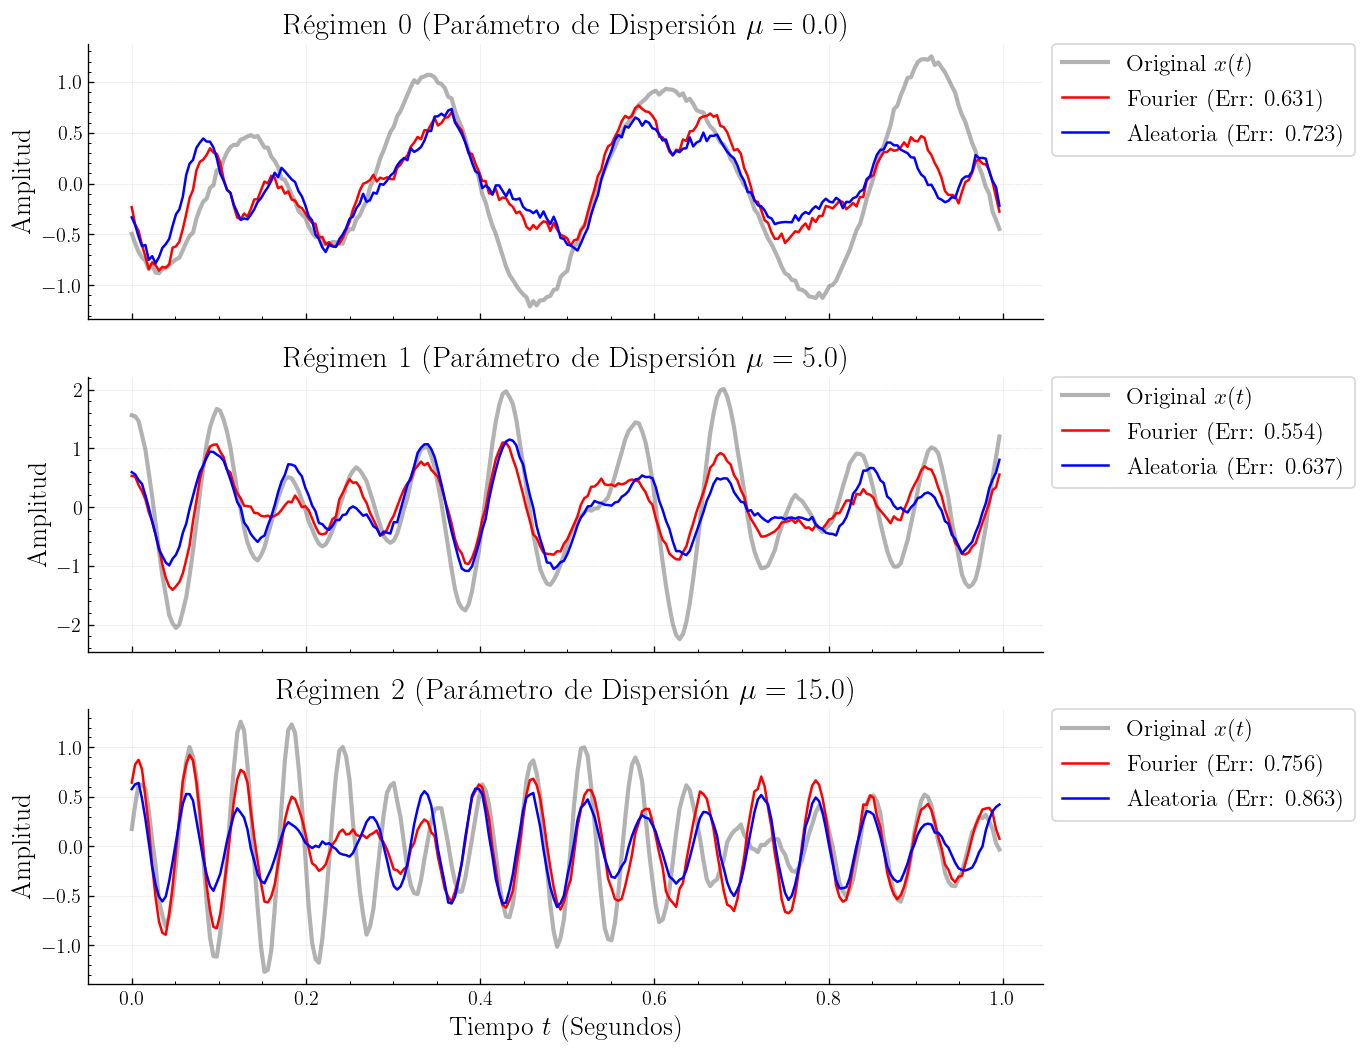

In [13]:
#llamando a la funcion de la red
historiales, p_rand, p_four = entrenar_red_fourier(X_train, y_train, W1_fourier_init, K=25, eta=0.02, iteraciones=3000, seed=3951)

# GRAFICA 1: Reconstrucciones finales para cada régimen dispersivo
X_hat_final_rand = forward_batch(p_rand, X_train) #predicción final con la red aleatoria  (forrward_branch hace que los datos pasen por la red)
X_hat_final_four = forward_batch(p_four, X_train) #predicción final con la red de Fourier
valores_mu = {0: "0.0", 1: "5.0", 2: "15.0"} #diccionario para el paramentro fisico real del valor de miu (los de los regimenes)

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True) #crea las 3 sub-graficas de la grafica de los 3 regímenes

print("ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN")

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0] #obtiene el indice de la primera senal representativa de cada régimen
    #calcula el error relativo final individual para cada una de las inicializacaiones
    err_f = np.linalg.norm(X_hat_final_four[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    err_r = np.linalg.norm(X_hat_final_rand[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    print(f"Régimen {reg} (mu={valores_mu[reg]}): Fourier Err = {err_f:.4f} | Aleatorio Err = {err_r:.4f}")

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.5) #Grafica la señal original
    axs[reg].plot(t, X_hat_final_four[idx], 'r', label=r'$\text{Fourier (Err: ' + f'{err_f:.3f}' + ')}$') #grafica la reconstrucción con Fourier
    axs[reg].plot(t, X_hat_final_rand[idx], 'b', label=r'$\text{Aleatoria (Err: ' + f'{err_r:.3f}' + ')}$') #grafica la reconstrucción con la inicializacion aleatoria

    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (Parámetro de Dispersión } \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.) #posición de la leyenda
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.80)
print("\n")
plt.show()

# Comparación de inicializaciones
curvas de la pérdida L vs iteraciones en escala loglog.
Analisis del regimen cero.

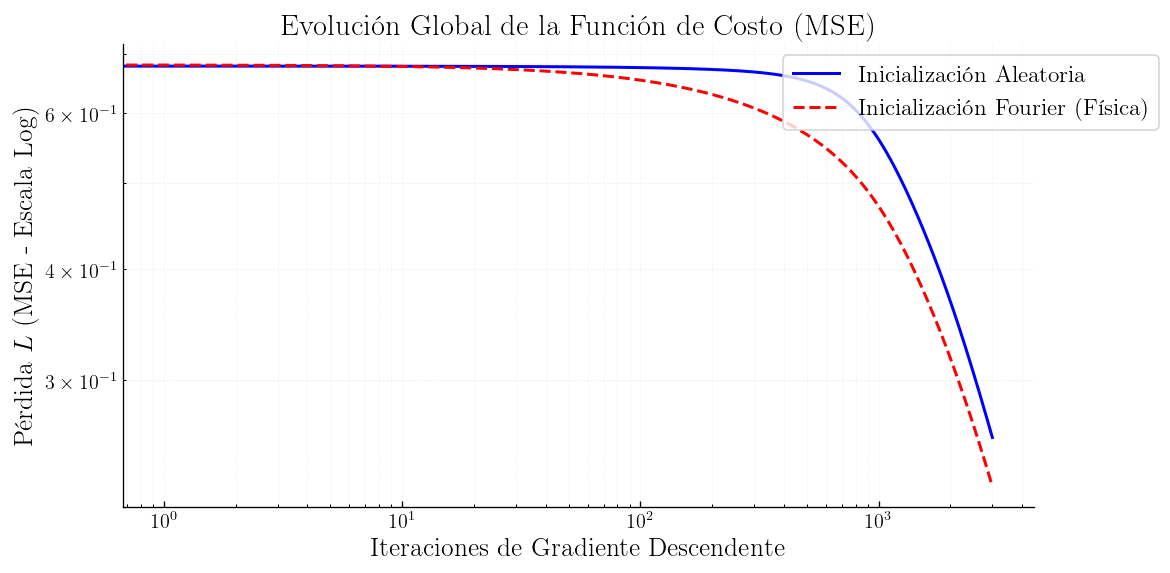

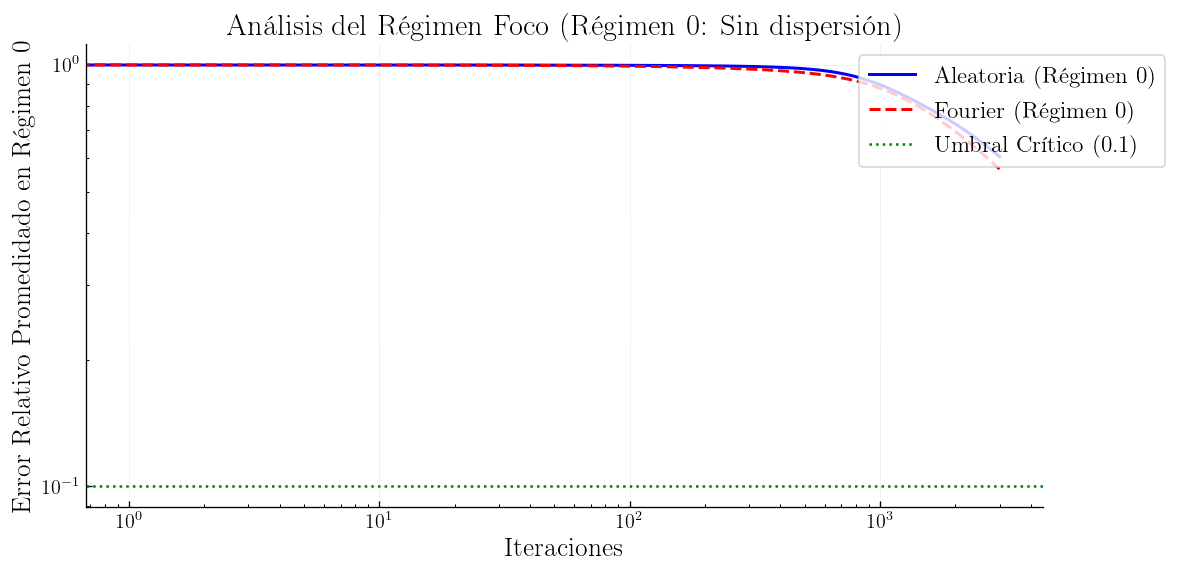

In [14]:
# GRAFICA 2: Pérdida Global
plt.figure(figsize=(10, 5))
# Grafica las curvas de pérdida global en escala doble logarítmica (loglog) para estudiar el comportamiento inicial
plt.loglog(historiales['loss_rand'], 'b-', label=r'$\text{Inicialización Aleatoria}$', linewidth=1.8)
plt.loglog(historiales['loss_four'], 'r--', label=r'$\text{Inicialización Fourier (Física)}$', linewidth=1.8)

plt.xlabel(r'$\text{Iteraciones de Gradiente Descendente}$')
plt.ylabel(r'$\text{Pérdida } L \text{ (MSE - Escala Log)}$')
plt.title(r'$\mathbf{\text{Evolución Global de la Función de Costo (MSE)}}$')
plt.grid(True, which="both", ls=":")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

# GRAFICA 3. Analisis de convergencia en el régimen 0
plt.figure(figsize=(10, 5))
# Grafica el descenso del error relativo exclusivo del régimen sin dispersión (mu=0.0)
plt.loglog(historiales['err_rand_r0'], 'b-', label=r'$\text{Aleatoria (Régimen 0)}$', linewidth=1.8)
plt.loglog(historiales['err_four_r0'], 'r--', label=r'$\text{Fourier (Régimen 0)}$', linewidth=1.8)
# Dibuja la línea horizontal crítica punteada fija en el umbral objetivo de 0.1 solicitado
plt.axhline(y=0.1, color='g', linestyle=':', label=r'$\text{Umbral Crítico (0.1)}$')
plt.xlabel(r'$\text{Iteraciones}$')
plt.ylabel(r'$\text{Error Relativo Promedidado en Régimen 0}$')
plt.title(r'$\mathbf{\text{Análisis del Régimen Foco (Régimen 0: Sin dispersión)}}$')
plt.grid(True)
plt.legend(loc='upper right', bbox_to_anchor=(1.14, 1))
plt.tight_layout()
plt.show()

Medición de cuántas iteraciones necesita cada inicialización para que el error relativo sea 0.1.


In [15]:
# 1. Llamas a la función con las 50,000 iteraciones
historiales, p_rand, p_four = entrenar_red_fourier(
    X_train, y_train, W1_fourier_init, K=25, eta=0.02, iteraciones=50000, seed=3951
)

# 2Función para encontrar la iteración exacta de convergencia
def buscar_iteracion_umbral(historial, umbral):
    for idx, val in enumerate(historial): #Recorre la lista registrando el la interacion actual (idx) y el valor de su error relativo
        if val <= umbral:
            return f"Alcanzó el umbral global en la iteración {idx}." # Rompe la función y reporta éxito inmediato

    # Si el ciclo termina por completo sin bajar del umbral, calcula el tamaño real evaluado y reporta el valor mínimo alcanzado
    return f"No alcanzó el umbral en {len(historial) - 1} iteraciones (Mínimo alcanzado: {min(historial):.4f})"


print("MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)")

# Analiza los resultados buscando de manera independiente dentro de las listas globales guardadas en 'historiales'
print(f"-> Inicialización Aleatoria: {buscar_iteracion_umbral(historiales['err_rand_global'], 0.1)}")
print(f"-> Inicialización de Fourier: {buscar_iteracion_umbral(historiales['err_four_global'], 0.1)}")

Entrenando redes (K=25, eta=0.02, iteraciones=50000)...
MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)
-> Inicialización Aleatoria: Alcanzó el umbral global en la iteración 27764.
-> Inicialización de Fourier: Alcanzó el umbral global en la iteración 24021.


# Compresión
Gráfica: error de reconstrucción vs número de coeficientes conservados. Primero para todos los coeficientes (de 1 a 50) con el 85% de energía señalado.

Con el número de coeficientes, se grafica cada régimen con esos coeficientes y se compara con la señal original.

ANÁLISIS DE COMPRESIÓN 
Coeficientes mínimos necesarios para alcanzar el 85% de energía: 5
Porcentaje de compresión del espacio: 90.00%



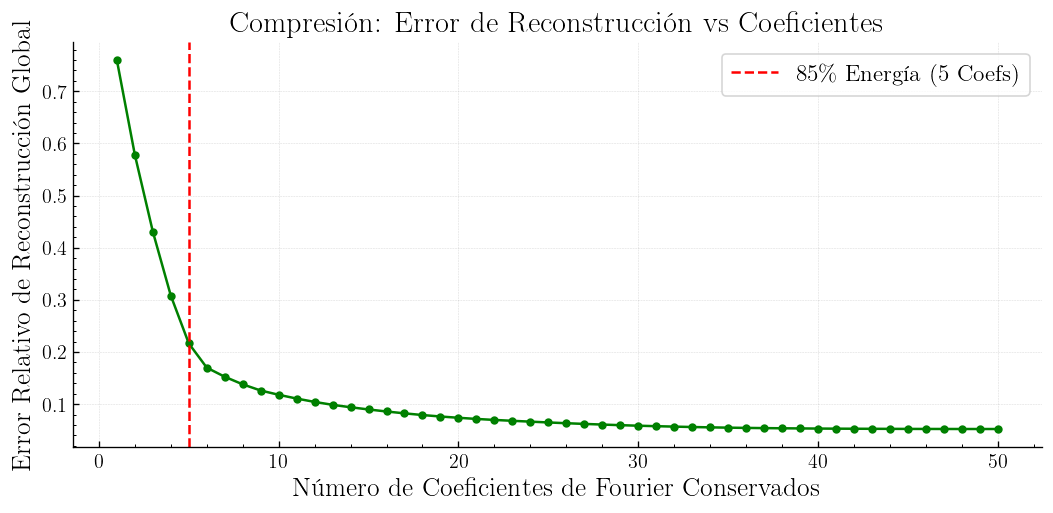

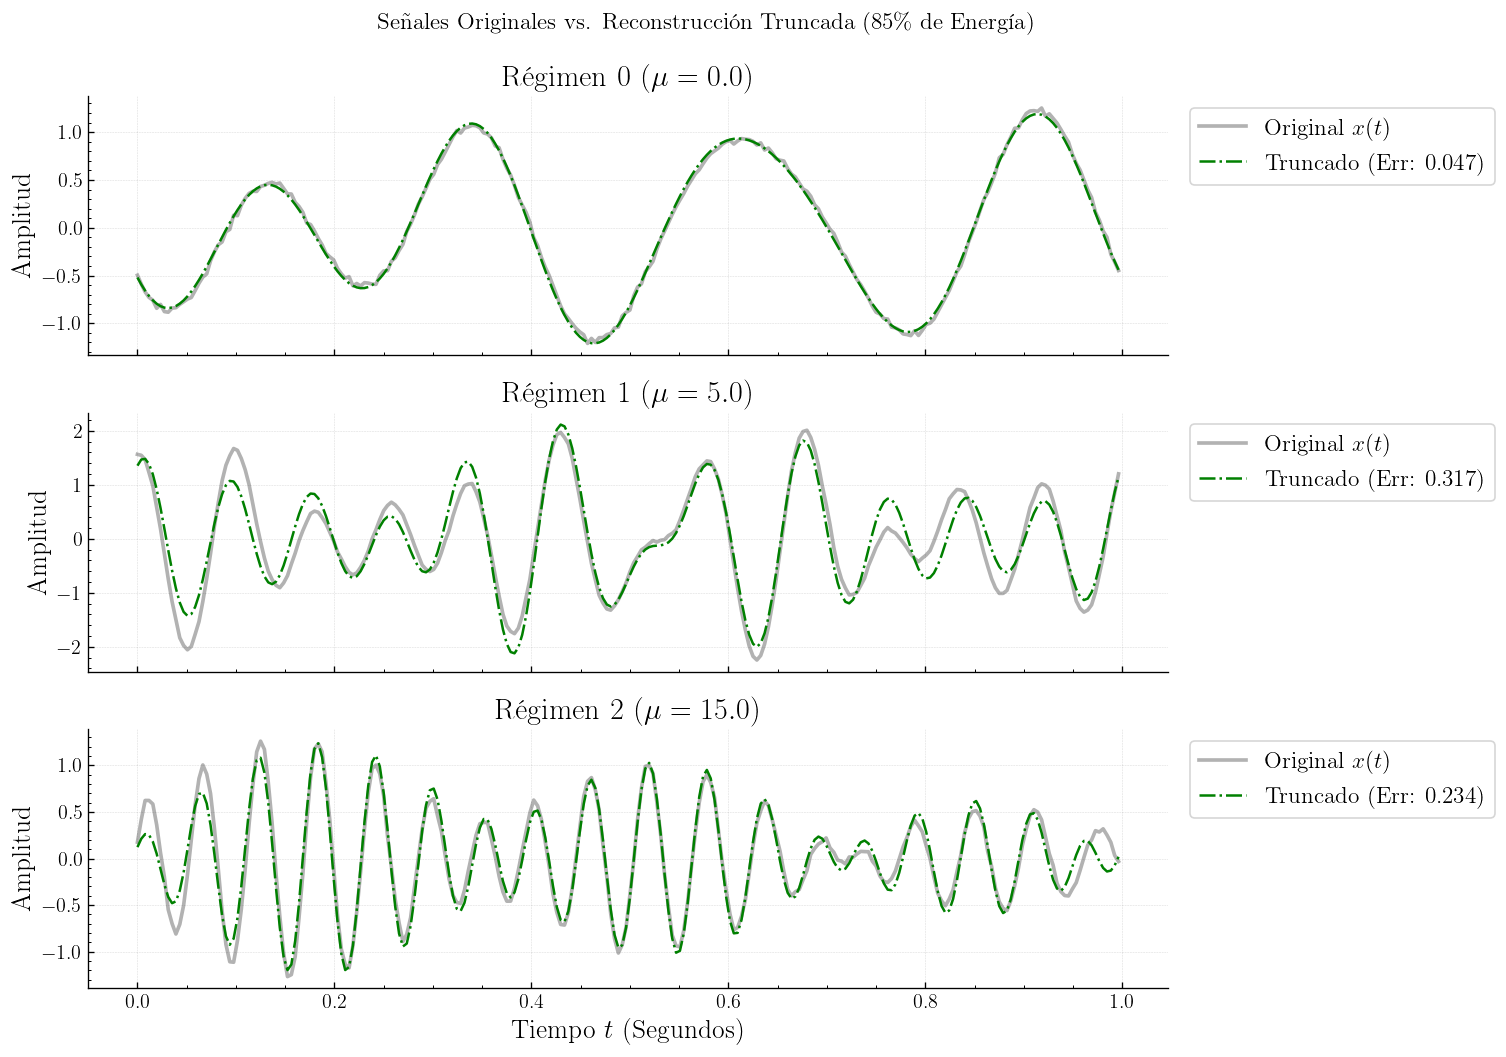

In [16]:
# Proyección de señales sobre la base compacta de Fourier
coeficientes_fourier = np.dot(np.array(X_train), W1_fourier_init.T)  #dot es un producto punto
# Eleva al cuadrado los coeficientes espectrales para mapear la potencia o energía contenida en cada frecuencia
energia_componentes = coeficientes_fourier ** 2

# Ordena la energía de cada una de las señales de mayor a menor importancia espectral (Eje 1: Columnas)
energia_ordenada = np.sort(energia_componentes, axis=1)[:, ::-1]
# Suma la energía total absoluta contenida en cada señal individual manteniendo las dimensiones de renglón
energia_total = np.sum(energia_ordenada, axis=1, keepdims=True)
# Saca la suma acumulada (cumsum) integrada de la energía y la normaliza dividiendo entre su energía total disponible
energia_acumulada_relativa = np.cumsum(energia_ordenada, axis=1) / energia_total #cumsum, suma acumulada de las energias

# Determinar componentes exactas para superar el 85% de la energía
UMBRAL_ENERGIA = 0.85 #segun enunciado_3951: umbral 85%
# Encuentra la primera columna (frecuencia ordenada) donde se logra pasar la meta del 85% y le ajusta el desfasamiento (+1)
componentes_por_senal = np.argmax(energia_acumulada_relativa >= UMBRAL_ENERGIA, axis=1) + 1#maximizando la energia
# Calcula el promedio de componentes necesarias de todas las señales y aplica un redondeo al entero superior inmediato (ceil)
componentes_necesarias_promedio = int(np.ceil(np.mean(componentes_por_senal))) #mean es el promedio, ceil entero superior

print("ANÁLISIS DE COMPRESIÓN ")

print(f"Coeficientes mínimos necesarios para alcanzar el 85% de energía: {componentes_necesarias_promedio}")
# Evalúa el porcentaje matemático de ahorro espacial: (1 - Coeficientes_conservados / Dimension_inicial_50) * 100
print(f"Porcentaje de compresión del espacio: {((1 - componentes_necesarias_promedio/hidden_dim)*100):.2f}%\n")

# Reconstrucción truncada
# Inicializa un bloque de ceros del mismo tamaño de X_train para guardar las señales reconstruidas de forma truncada
X_train_reconstruido_fourier = np.zeros_like(X_train) #un x_train de ceros, una inicialización
# Calcula la matriz pseudo-inversa de Moore-Penrose para regresar del espacio frecuencial compacto (en el que se encuentra al multiplicarse por W1)de vuelta al dominio temporal para poder visualizar
base_fourier_pinv = np.linalg.pinv(W1_fourier_init.T)
#np.linalg.pinv es una matriz no cuadrada que es una aproximancion a una inversa (que debe ser cuadrada), para asi pasar la matriz al espacio en que la necesitamos
# Bucle encargado de reconstruir las señales truncadas de forma manual
for idx in range(X_train.shape[0]):
    coefs = coeficientes_fourier[idx].copy() # Extrae una copia independiente de los componentes espectrales de la señal
    # Encuentra cuáles frecuencias caen por debajo del límite energético promedio permitido para compresión
    indices_baja_energia = np.argsort(energia_componentes[idx])[::-1][componentes_necesarias_promedio:] #np.argsort devuelve los indices que ordenarian un arreglo de menor a mayor, no los datos
    coefs[indices_baja_energia] = 0.0 # Apaga (pone en cero absoluto) los coeficientes innecesarios de baja energía
    X_train_reconstruido_fourier[idx] = np.dot(coefs, base_fourier_pinv) # Regresa al dominio temporal aplicando el producto punto con la base inversa truncada

# Evaluación paramétrica de error vs coeficientes para la curva verde
errores_por_coeficiente = [] # Lista para ir recolectando las magnitudes promedio de error de 1 a 50 componentes
for k_coef in range(1, hidden_dim + 1):
    err_acum = [] # Lista interna para recolectar el error de todo el dataset para un límite 'k_coef' fijo
    for idx in range(X_train.shape[0]):
        coefs = coeficientes_fourier[idx].copy()
        indices_baja_energia = np.argsort(energia_componentes[idx])[::-1][k_coef:] # Ordena las energías de menor a mayor y apaga los coeficientes sobrantes que excedan el límite de 'k_coef
        coefs[indices_baja_energia] = 0.0
        rec = np.dot(coefs, base_fourier_pinv) # Reconstrucción del vector temporal parcial
        # Calcula el error relativo cometido por esta pérdida selectiva de información armónica
        err_acum.append(np.linalg.norm(rec - X_train[idx]) / np.linalg.norm(X_train[idx]))
    errores_por_coeficiente.append(np.mean(err_acum)) # Almacena el promedio global de error de reconstrucción matemática para este número exacto de términos conservados

# GRÁFICA 4
plt.figure(figsize=(9, 4.5))
# Dibuja la curva que describe el error conforme retenemos más coeficientes armónicos (de 1 a 50)
plt.plot(range(1, hidden_dim + 1), errores_por_coeficiente, 'g-o', markersize=4)
# Dibuja la línea vertical roja punteada que marca el número exacto donde se alcanza la meta de energía del 85%
plt.axvline(x=componentes_necesarias_promedio, color='r', linestyle='--',
            label=r'$85\%\text{ Energía (' + str(componentes_necesarias_promedio) + r' Coefs)}$')
plt.xlabel(r'$\text{Número de Coeficientes de Fourier Conservados}$')
plt.ylabel(r'$\text{Error Relativo de Reconstrucción Global}$')
plt.title(r'$\mathbf{\text{Compresión: Error de Reconstrucción vs Coeficientes}}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Grafica 5: Visualización Temporal de la Señal Truncada por Régimen
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True) # Genera una matriz vertical de 3 sub-gráficos temporales
fig.suptitle(r'$\mathbf{\text{Señales Originales vs. Reconstrucción Truncada (85\% de Energía)}}$', fontsize=14, y=0.98)

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0] # Localiza la primera muestra representante de cada régimen dispersivo
    # Calcula el error cometido debido puramente a la eliminación matemática de frecuencias irrelevantes (truncamiento)
    err_trunc = np.linalg.norm(X_train_reconstruido_fourier[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    # Dibuja la señal original pura
    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.2)
    axs[reg].plot(t, X_train_reconstruido_fourier[idx], 'g-.', label=r'$\text{Truncado (Err: ' + f'{err_trunc:.3f}' + ')}$')
    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (} \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0)) # Mueve la leyenda a un lado para dejar ver las ondas
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.show()